In [25]:
import fastf1
import pandas as pd
import numpy as np
import sklearn
import os
import time

print("fastf1 version:", fastf1.__version__)
print("fastf1 version:", pd.__version__)
print("sklearn version:", sklearn.__version__)


fastf1 version: 3.8.0
fastf1 version: 2.3.3
sklearn version: 1.8.0


In [26]:
session = fastf1.get_session(2026,"Australian Grand Prix","r")
session.load(telemetry= False, weather = False, messages = False)

results = session.results

results = results.drop(columns=["BroadcastName", "Abbreviation", "TeamColor", "HeadshotUrl", "CountryCode", "ClassifiedPosition"])
print(results.columns)
print(results.head(5))
results.to_csv('AustralianGpP.csv', index = False)

core           INFO 	Loading data for Australian Grand Prix - Race [v3.8.0]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
core        WARNING 	No lap data for driver 81
core        WARNING 	Failed to perform lap accuracy check - all laps marked as inaccurate (driver 81)
core           INFO 	Finished loading data for 22 drivers: ['63', '12', '16', '44', '1', '3', '87', '41', '5', '10', '31', '23', '30', '43', '55', '11', '18', '14', '77', '6', '81', '27']


Index(['DriverNumber', 'DriverId', 'TeamName', 'TeamId', 'FirstName',
       'LastName', 'FullName', 'Position', 'GridPosition', 'Q1', 'Q2', 'Q3',
       'Time', 'Status', 'Points', 'Laps'],
      dtype='object')
   DriverNumber   DriverId  TeamName    TeamId FirstName   LastName  \
63           63    russell  Mercedes  mercedes    George    Russell   
12           12  antonelli  Mercedes  mercedes      Kimi  Antonelli   
16           16    leclerc   Ferrari   ferrari   Charles    Leclerc   
44           44   hamilton   Ferrari   ferrari     Lewis   Hamilton   
1             1     norris   McLaren   mclaren     Lando     Norris   

           FullName  Position  GridPosition  Q1  Q2  Q3  \
63   George Russell       1.0           1.0 NaT NaT NaT   
12   Kimi Antonelli       2.0           2.0 NaT NaT NaT   
16  Charles Leclerc       3.0           4.0 NaT NaT NaT   
44   Lewis Hamilton       4.0           7.0 NaT NaT NaT   
1      Lando Norris       5.0           6.0 NaT NaT NaT   

     

In [27]:

# def time_to_seconds(t):
#     try:
#         return round(pd.to_timedelta(str(t)).total_seconds(), 3)
#     except:
#         return None

# def load_race_weekend(year, round_num):
#     try:
#         # Qualifying
#         quali = fastf1.get_session(year, round_num, 'Q')
#         quali.load(telemetry=False, weather=False, messages=False)
        
#         quali_df = quali.results[[
#             'DriverNumber', 'FullName', 'TeamName',
#             'Position', 'Q1', 'Q2', 'Q3'
#         ]].copy()
#         quali_df = quali_df.rename(columns={'Position': 'GridPosition'})
#         quali_df['Q1_seconds'] = quali_df['Q1'].apply(time_to_seconds)
#         quali_df['Q2_seconds'] = quali_df['Q2'].apply(time_to_seconds)
#         quali_df['Q3_seconds'] = quali_df['Q3'].apply(time_to_seconds)
#         quali_df = quali_df.drop(columns=['Q1', 'Q2', 'Q3'])

#         # Race
#         race = fastf1.get_session(year, round_num, 'R')
#         race.load(telemetry=False, weather=False, messages=False)
        
#         race_df = race.results[['FullName', 'Position', 'Status', 'Points', 'Time']].copy()
#         race_df['TimeDelta'] = race_df['Time'].apply(time_to_seconds)
#         race_df = race_df.rename(columns={'Position': 'RacePosition'})
#         race_df = race_df.drop(columns='Time')

#         # Merge
#         merged = pd.merge(quali_df, race_df, on='FullName', how='inner')
#         merged['Season'] = year
#         merged['Round'] = round_num
#         merged['EventName'] = race.event['EventName']
#         merged['FinishPosition'] = pd.to_numeric(merged['RacePosition'], errors='coerce')

#         return merged

#     except Exception as e:
#         print(f"  âœ— Round {round_num} skipped: {e}")
#         return None


# # â”€â”€ Run with resume support â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
# all_seasons = []

# for year in range(2025, 2026):
#     print(f"\n{'='*40}")
#     print(f"  Loading {year}...")
#     print(f"{'='*40}")

#     season_file = f'data/f1_{year}.csv'
#     schedule = fastf1.get_event_schedule(year, include_testing=False)
#     all_rounds = list(schedule['RoundNumber'])

#     # â”€â”€ Resume logic â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
#     existing_df = None
#     completed_rounds = set()

#     if os.path.exists(season_file):
#         existing_df = pd.read_csv(season_file)
#         completed_rounds = set(existing_df['Round'].unique())
#         print(f"  âœ“ Found existing data â€” {len(completed_rounds)} rounds already loaded: {sorted(completed_rounds)}")
    
#     remaining_rounds = [r for r in all_rounds if r not in completed_rounds]

#     if not remaining_rounds:
#         print(f"  âœ“ All rounds complete â€” loading from CSV")
#         all_seasons.append(existing_df)
#         continue

#     print(f"  â†’ Rounds to fetch: {remaining_rounds}")

#     # â”€â”€ Fetch missing rounds â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
#     season_data = []
#     for round_num in remaining_rounds:
#         print(f"Loading round {round_num}...", end=' ')
#         df = load_race_weekend(year, round_num)
#         if df is not None:
#             season_data.append(df)
#             print(f"âœ“ {df['EventName'].iloc[0]}")
#         time.sleep(3)

#     # â”€â”€ Merge new data with existing and save â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
#     frames = []
#     if existing_df is not None:
#         frames.append(existing_df)
#     if season_data:
#         frames.append(pd.concat(season_data, ignore_index=True))

#     if frames:
#         year_df = pd.concat(frames, ignore_index=True)
#         year_df = year_df.sort_values('Round').reset_index(drop=True)  # keep rounds in order
#         year_df.to_csv(season_file, index=False)
#         print(f"  âœ“ Saved {len(year_df['Round'].unique())} total rounds for {year}")
#         all_seasons.append(year_df)

#     print(f"\nDone!")

In [28]:

# Load and combine all seasons
years = range(2020, 2026)  # 2020-2024
dfs = [pd.read_csv(f'data/f1_{year}.csv') for year in years]

combined = pd.concat(dfs, ignore_index=True)
combined = combined.sort_values(['Season', 'Round']).reset_index(drop=True)


combined.to_csv('data/f1_2020_2025.csv', index=False)
print(f"Combined dataset: {len(combined)} rows across {combined['Season'].nunique()} seasons")

Combined dataset: 2617 rows across 6 seasons


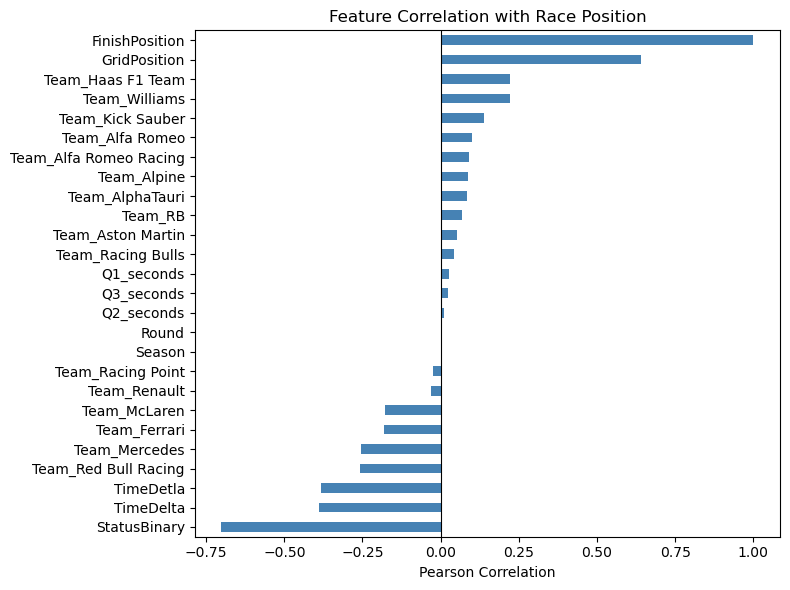

In [29]:
import seaborn as sns
import matplotlib.pyplot as plt


df = pd.read_csv('data/f1_2020_2025.csv')

df["StatusBinary"] = df["Status"].eq("Finished").astype(int)

df_fin = df[df["Status"] == "Finished"].copy()

df = df.drop(columns = ['Time', 'Podium', 'Points', 'Status', 'DriverNumber'])



team_dummies = pd.get_dummies(df["TeamName"], prefix="Team")

df_numeric = pd.concat([df.drop(columns=['TeamName', 'FullName', 'EventName']), team_dummies], axis = 1)

df_numeric.head()

corr_matrix = df_numeric.corr()['RacePosition'].drop('RacePosition').sort_values()

corr_matrix.plot(kind='barh', figsize=(8, 6), color='steelblue')
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Feature Correlation with Race Position')
plt.xlabel('Pearson Correlation')
plt.tight_layout()
plt.show()


Text(0.5, 1.0, 'Race Finish vs Grid Position')

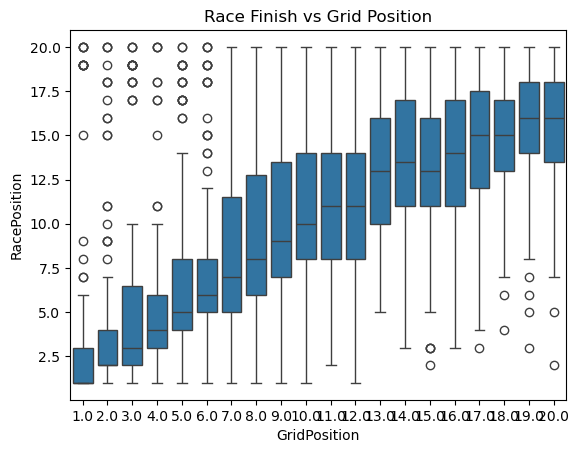

In [30]:
sns.boxplot(data = df, x = 'GridPosition', y ='RacePosition')
plt.title('Race Finish vs Grid Position')

In [31]:

for year in range(2020, 2025):
    newDF = pd.read_csv(f'data/f1_{year}.csv') 
    drivers = newDF.groupby('TeamName')['RacePosition'].agg(['mean', 'std']).sort_values('mean')
    print(f"\n DRIVER STATS FOR {year}")
    print(f"{'=' * 40}")
    print(drivers)


 DRIVER STATS FOR 2020
                        mean       std
TeamName                              
Mercedes            3.735294  4.223375
Red Bull Racing     7.705882  6.206201
McLaren             8.617647  4.817988
Renault             8.941176  4.741443
Racing Point        9.205882  5.902128
Ferrari            10.705882  5.390954
AlphaTauri         10.705882  4.713163
Alfa Romeo Racing  13.852941  2.786682
Williams           15.735294  2.632073
Haas F1 Team       15.794118  2.804535

 DRIVER STATS FOR 2021
                        mean       std
TeamName                              
Mercedes            5.409091  5.743827
Red Bull Racing     5.840909  6.069149
Ferrari             7.113636  3.948599
McLaren             7.795455  3.915263
Alpine             10.250000  4.636182
AlphaTauri         11.272727  5.271087
Aston Martin       12.000000  4.404015
Alfa Romeo Racing  13.204545  2.698661
Williams           14.727273  3.787149
Haas F1 Team       17.325581  1.972682

 DRIVER STATS F

In [32]:
#Based on the above data, it's clear that there is a decline in race finish position from
#Lewis hamilton, while there is an increase in performance from Lando for example
#Because of this, it would be good to encode some sort of weighting system for recent performance more than older performances
#for both the drivers and teams

df = pd.read_csv('data/f1_2020_2025.csv')

df = df.sort_values(['Season', 'Round']).reset_index(drop=True)

df['driver_rolling_avg_3'] = (
    df.groupby('FullName')['RacePosition']
    .transform(lambda x: x.shift(1).rolling(window=3, min_periods=1).mean())
)

df['driver_rolling_avg_5'] = (
    df.groupby('FullName')['RacePosition']
    .transform(lambda x: x.shift(1).rolling(window=5, min_periods=1).mean())
)

# Rolling std deviation (consistency metric)
df['driver_rolling_std_5'] = (
    df.groupby('FullName')['RacePosition']
    .transform(lambda x: x.shift(1).rolling(window=5, min_periods=1).std())
)

# Last race finish (most recent form signal)
df['driver_last_finish'] = (
    df.groupby('FullName')['RacePosition']
    .transform(lambda x: x.shift(1))
)

print(f"{'=' * 40}")
print("\n Successfully Added Rolling Averages for the past 3 and 5 races for all drivers")


 Successfully Added Rolling Averages for the past 3 and 5 races for all drivers


In [33]:
#Adding rolling averages for teams and their positions
df['team_rolling_avg_5'] = (
    df.groupby('TeamName')['RacePosition']
    .transform(lambda x: x.shift(1).rolling(window=5, min_periods=1).mean())
)

df['team_rolling_avg_3'] = (
    df.groupby('TeamName')['RacePosition']
    .transform(lambda x: x.shift(1).rolling(window=3, min_periods=1).mean())
)

print(f"{'=' * 40}")
print("\n Successfully Added Rolling Averages for the past 3 and 5 races for all teams")


 Successfully Added Rolling Averages for the past 3 and 5 races for all teams


In [34]:

print(df.columns)

Index(['DriverNumber', 'FullName', 'TeamName', 'GridPosition', 'Q1_seconds',
       'Q2_seconds', 'Q3_seconds', 'RacePosition', 'Status', 'Points',
       'TimeDelta', 'Season', 'Round', 'EventName', 'FinishPosition', 'Time',
       'TimeDetla', 'Podium', 'driver_rolling_avg_3', 'driver_rolling_avg_5',
       'driver_rolling_std_5', 'driver_last_finish', 'team_rolling_avg_5',
       'team_rolling_avg_3'],
      dtype='object')


In [35]:
# Step 1: Get each driver's qualifying time (use best available Q time)
df['best_q_time'] = df['Q3_seconds'].fillna(df['Q2_seconds']).fillna(df['Q1_seconds'])

# Step 2: Calculate teammate's best Q time for the same race
teammate_avg = (
    df.groupby(['Season', 'Round', 'TeamName'])['best_q_time']
    .transform('mean')
)

# Step 3: Delta = driver's time minus team average
# Positive = slower than teammate, Negative = faster than teammate
df['quali_delta_to_teammate'] = df['best_q_time'] - teammate_avg

In [36]:
# Pick a race and check Hamilton vs Bottas
check = df[
    (df['Season'] == 2020) & 
    (df['Round'] == 1) & 
    (df['TeamName'] == 'Mercedes')
][['FullName', 'best_q_time', 'quali_delta_to_teammate']]
print(check)


          FullName  best_q_time  quali_delta_to_teammate
0  Valtteri Bottas       62.939                   -0.006
1   Lewis Hamilton       62.951                    0.006


In [37]:

# Step 1 - rename and drop redundant columns
df = df.drop(columns=['DriverNumber', 'FinishPosition'])
df = df.rename(columns={'RacePosition': 'FinishPosition'})


# Step 2 - clean TimeDelta and engineer rolling features
df = df.sort_values(['FullName', 'Season', 'Round'])
df.loc[df['FinishPosition'] == 1, 'TimeDelta'] = 0

df['TimeDelta'] = df['TimeDelta'].fillna(300)

df['driver_rolling_avg_timedelta_3'] = (
    df.groupby('FullName')['TimeDelta']
    .transform(lambda x: x.shift(1).rolling(window=3, min_periods=1).mean())
)
df['driver_rolling_avg_timedelta_5'] = (
    df.groupby('FullName')['TimeDelta']
    .transform(lambda x: x.shift(1).rolling(window=5, min_periods=1).mean())
)
train_timedelta_mean = df[df['Season'] <= 2024]['TimeDelta'].mean()
df['driver_rolling_avg_timedelta_3'] = df['driver_rolling_avg_timedelta_3'].fillna(train_timedelta_mean)
df['driver_rolling_avg_timedelta_5'] = df['driver_rolling_avg_timedelta_5'].fillna(train_timedelta_mean)

# Step 3 - drop leakage
leakage = ['Points', 'TimeDelta', 'TimeDetla', 'Podium', 'Status', 'Time']
df = df.drop(columns=leakage)

df_ref = df[['Season', 'Round', 'EventName', 'FullName', 'FinishPosition']].copy()

# Step 4 - encode categoricals and join back
teamDummy = pd.get_dummies(df['TeamName'], prefix='Team')
driverDummy = pd.get_dummies(df['FullName'], prefix='Driver')
eventDummy = pd.get_dummies(df['EventName'], prefix='Event')
df = df.drop(columns=['TeamName', 'FullName', 'EventName'])
df = pd.concat([df, teamDummy, driverDummy, eventDummy], axis=1)

print(df.shape)
print(df.columns)


(2617, 106)
Index(['GridPosition', 'Q1_seconds', 'Q2_seconds', 'Q3_seconds',
       'FinishPosition', 'Season', 'Round', 'driver_rolling_avg_3',
       'driver_rolling_avg_5', 'driver_rolling_std_5',
       ...
       'Event_Russian Grand Prix', 'Event_Sakhir Grand Prix',
       'Event_Saudi Arabian Grand Prix', 'Event_Singapore Grand Prix',
       'Event_Spanish Grand Prix', 'Event_Styrian Grand Prix',
       'Event_São Paulo Grand Prix', 'Event_Turkish Grand Prix',
       'Event_Tuscan Grand Prix', 'Event_United States Grand Prix'],
      dtype='object', length=106)


In [38]:
print(len(df[df['Driver_Max Verstappen'] == 1]))

131


In [39]:
print(df.isnull().sum())


GridPosition                         2
Q1_seconds                          30
Q2_seconds                         679
Q3_seconds                        1336
FinishPosition                       3
                                  ... 
Event_Styrian Grand Prix             0
Event_São Paulo Grand Prix           0
Event_Turkish Grand Prix             0
Event_Tuscan Grand Prix              0
Event_United States Grand Prix       0
Length: 106, dtype: int64


In [40]:
df = df.dropna(subset=['best_q_time'])

In [41]:
# Get all dummy columns
dummy_cols = [col for col in df.columns if col.startswith('Driver_') or col.startswith('Team_')]

# Correlate with FinishPosition only
dummy_corr = df[dummy_cols + ['FinishPosition']].corr()['FinishPosition'].drop('FinishPosition')

# Show top 10 most correlated (positive and negative)
print("Most positive correlation:")
print(dummy_corr.sort_values(ascending=False).head(10))

print("\nMost negative correlation:")
print(dummy_corr.sort_values(ascending=True).head(10))



Most positive correlation:
Team_Haas F1 Team         0.223742
Team_Williams             0.218636
Driver_Nicholas Latifi    0.145581
Team_Kick Sauber          0.136338
Driver_Kevin Magnussen    0.133731
Driver_Guanyu Zhou        0.117231
Driver_Nikita Mazepin     0.114725
Driver_Mick Schumacher    0.113001
Driver_Logan Sargeant     0.112155
Driver_Yuki Tsunoda       0.104743
Name: FinishPosition, dtype: float64

Most negative correlation:
Driver_Max Verstappen    -0.266835
Team_Red Bull Racing     -0.256022
Team_Mercedes            -0.253570
Driver_Lewis Hamilton    -0.188536
Team_Ferrari             -0.179866
Team_McLaren             -0.175642
Driver_Lando Norris      -0.153115
Driver_Charles Leclerc   -0.140266
Driver_Sergio Perez      -0.114815
Driver_Oscar Piastri     -0.110706
Name: FinishPosition, dtype: float64


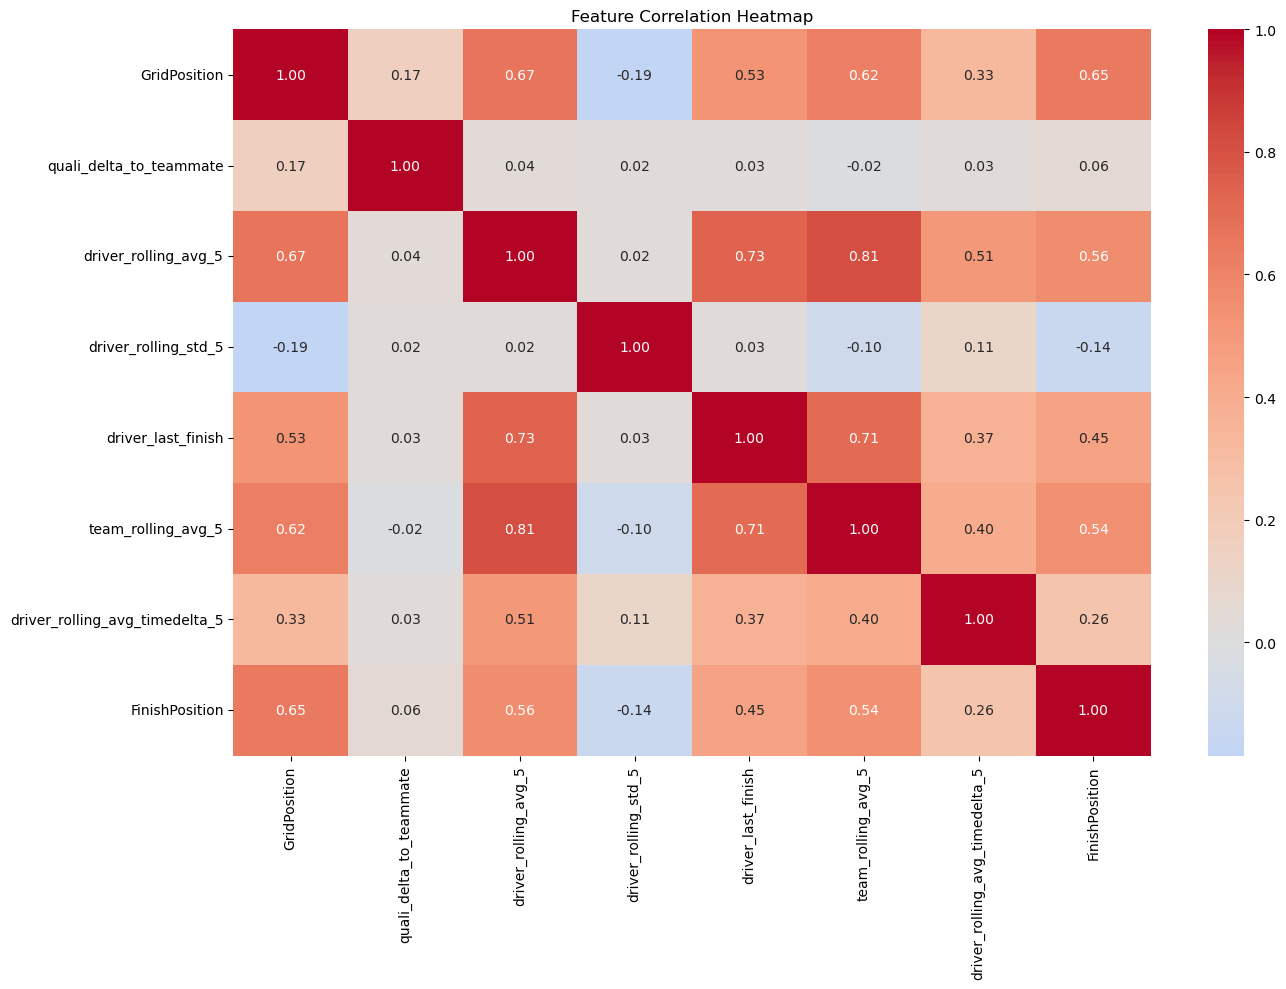

In [42]:

# Only include numeric columns, exclude dummy columns
numeric_cols = ['GridPosition', 'quali_delta_to_teammate',
                'driver_rolling_avg_5', 'driver_rolling_std_5', 'driver_last_finish',
                'team_rolling_avg_5', 
                'driver_rolling_avg_timedelta_5', 'FinishPosition']

corr = df[numeric_cols].corr()

plt.figure(figsize=(14, 10))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.show()

In [43]:
df = df.drop(columns = ['driver_rolling_avg_timedelta_3', 'team_rolling_avg_3', 'Q1_seconds', 'Q2_seconds', 'Q3_seconds', 'best_q_time'])

In [ ]:
# === EDA: Position Variance by Track (2020–2024) ===
import matplotlib.cm as cm

_raw = pd.read_csv('data/f1_2020_2025.csv')
_raw = _raw[_raw['Season'] <= 2024].copy()

# Positive delta = gained positions, negative = lost
_raw['positions_delta'] = _raw['GridPosition'] - _raw['FinishPosition']

def _avg_gained(x):
    gains = x[x > 0]
    return gains.mean() if len(gains) > 0 else 0.0

def _avg_lost(x):
    losses = x[x < 0]
    return losses.mean() if len(losses) > 0 else 0.0

track_stats = _raw.groupby('EventName')['positions_delta'].agg(
    mean_abs_delta=lambda x: x.abs().mean(),
    std_delta='std',
    median_delta='median',
    avg_gained=_avg_gained,
    avg_lost=_avg_lost
).reset_index().sort_values('mean_abs_delta', ascending=True)

# Horizontal bar chart colored by std deviation
fig, ax = plt.subplots(figsize=(10, 10))
norm = plt.Normalize(track_stats['std_delta'].min(), track_stats['std_delta'].max())
colors = cm.RdYlGn_r(norm(track_stats['std_delta']))
ax.barh(track_stats['EventName'], track_stats['mean_abs_delta'], color=colors)
sm = plt.cm.ScalarMappable(cmap='RdYlGn_r', norm=norm)
sm.set_array([])
plt.colorbar(sm, ax=ax, label='Std Dev of Delta (higher = more unpredictable)')
ax.set_xlabel('Mean Absolute Position Delta')
ax.set_title('Position Variance by Track (2020–2024)\nSorted by avg positions moved from grid')
plt.tight_layout()
plt.show()

print(track_stats.sort_values('mean_abs_delta', ascending=False).to_string(index=False))

In [44]:
#EDA IS NOW OVER

#WE MOVE INTO THE MODEL SELECTION
df_train = df[df['Season'] <= 2024]
df_eval = df[df['Season'] == 2025]

X_train = df_train.drop(columns=['FinishPosition', 'Season', 'Round'])
y_train = df_train['FinishPosition']

X_val = df_eval.drop(columns=['FinishPosition', 'Season', 'Round'])
y_val = df_eval['FinishPosition']



In [45]:
pd.set_option('display.max_columns', None)
mask = y_train.notna()
X_train = X_train[mask]
y_train = y_train[mask]

for i, col in enumerate(X_val.columns):
    print(i, col)



0 GridPosition
1 driver_rolling_avg_3
2 driver_rolling_avg_5
3 driver_rolling_std_5
4 driver_last_finish
5 team_rolling_avg_5
6 quali_delta_to_teammate
7 driver_rolling_avg_timedelta_5
8 Team_Alfa Romeo
9 Team_Alfa Romeo Racing
10 Team_AlphaTauri
11 Team_Alpine
12 Team_Aston Martin
13 Team_Ferrari
14 Team_Haas F1 Team
15 Team_Kick Sauber
16 Team_McLaren
17 Team_Mercedes
18 Team_RB
19 Team_Racing Bulls
20 Team_Racing Point
21 Team_Red Bull Racing
22 Team_Renault
23 Team_Williams
24 Driver_Alexander Albon
25 Driver_Andrea Kimi Antonelli
26 Driver_Antonio Giovinazzi
27 Driver_Carlos Sainz
28 Driver_Charles Leclerc
29 Driver_Daniel Ricciardo
30 Driver_Daniil Kvyat
31 Driver_Esteban Ocon
32 Driver_Fernando Alonso
33 Driver_Franco Colapinto
34 Driver_Gabriel Bortoleto
35 Driver_George Russell
36 Driver_Guanyu Zhou
37 Driver_Isack Hadjar
38 Driver_Jack Aitken
39 Driver_Jack Doohan
40 Driver_Kevin Magnussen
41 Driver_Kimi Antonelli
42 Driver_Kimi Räikkönen
43 Driver_Lance Stroll
44 Driver_Land

In [46]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(n_estimators = 100, max_depth = None, max_features = 'sqrt', min_samples_split = 2, random_state = 42)

rf.fit(X_train, y_train)

y_pred = rf.predict(X_val)

df_eval_ref = df_ref.loc[X_val.index].copy()
df_eval_ref['Predicted'] = y_pred
df_eval_ref['Predicted_Rank'] = df_eval_ref.groupby('EventName')['Predicted'].rank(method='first').astype(int)

race = df_eval_ref[df_eval_ref['EventName'] == 'Australian Grand Prix']
race = race.sort_values('Predicted_Rank')

df_eval_ref.sort_values(['Round', 'Predicted_Rank']).to_csv('f1_2025_predictions.csv', index=False)
print(race)


      Season  Round              EventName               FullName  \
2139    2025      1  Australian Grand Prix           Lando Norris   
2142    2025      1  Australian Grand Prix         George Russell   
2145    2025      1  Australian Grand Prix        Charles Leclerc   
2141    2025      1  Australian Grand Prix         Max Verstappen   
2140    2025      1  Australian Grand Prix          Oscar Piastri   
2146    2025      1  Australian Grand Prix         Lewis Hamilton   
2143    2025      1  Australian Grand Prix           Yuki Tsunoda   
2154    2025      1  Australian Grand Prix  Andrea Kimi Antonelli   
2147    2025      1  Australian Grand Prix           Pierre Gasly   
2148    2025      1  Australian Grand Prix           Carlos Sainz   
2149    2025      1  Australian Grand Prix           Isack Hadjar   
2150    2025      1  Australian Grand Prix        Fernando Alonso   
2144    2025      1  Australian Grand Prix        Alexander Albon   
2156    2025      1  Australian Gr

In [47]:
from scipy.stats import kendalltau
from sklearn.metrics import average_precision_score

# Per race metrics
tau_scores  = {}
mae_scores  = {}
ap5_scores  = {}
top5_scores = {}

for race in df_eval_ref['EventName'].unique():
    race_df = df_eval_ref[df_eval_ref['EventName'] == race].dropna(subset=['FinishPosition'])

    tau, _ = kendalltau(race_df['FinishPosition'], race_df['Predicted_Rank'])
    mae = (race_df['FinishPosition'] - race_df['Predicted_Rank']).abs().mean()

    actual_top5 = (race_df['FinishPosition'] <= 5).astype(int)
    ap5 = average_precision_score(actual_top5, -race_df['Predicted_Rank'])

    predicted_top5_names = set(race_df.nsmallest(5, 'Predicted_Rank')['FullName'])
    actual_top5_names    = set(race_df.nsmallest(5, 'FinishPosition')['FullName'])
    top5_precision = len(predicted_top5_names & actual_top5_names) / 5

    tau_scores[race]  = round(tau, 3)
    mae_scores[race]  = round(mae, 3)
    ap5_scores[race]  = round(ap5, 3)
    top5_scores[race] = round(top5_precision, 3)

print(f"Mean Kendall's Tau:   {np.mean(list(tau_scores.values())):.3f}")
print(f"Mean MAE:             {np.mean(list(mae_scores.values())):.3f} positions")
print(f"Mean AP@5:            {np.mean(list(ap5_scores.values())):.3f}")
print(f"Mean Top-5 Precision: {np.mean(list(top5_scores.values())):.3f}")

Mean Kendall's Tau: 0.510
Mean MAE:           3.422 positions


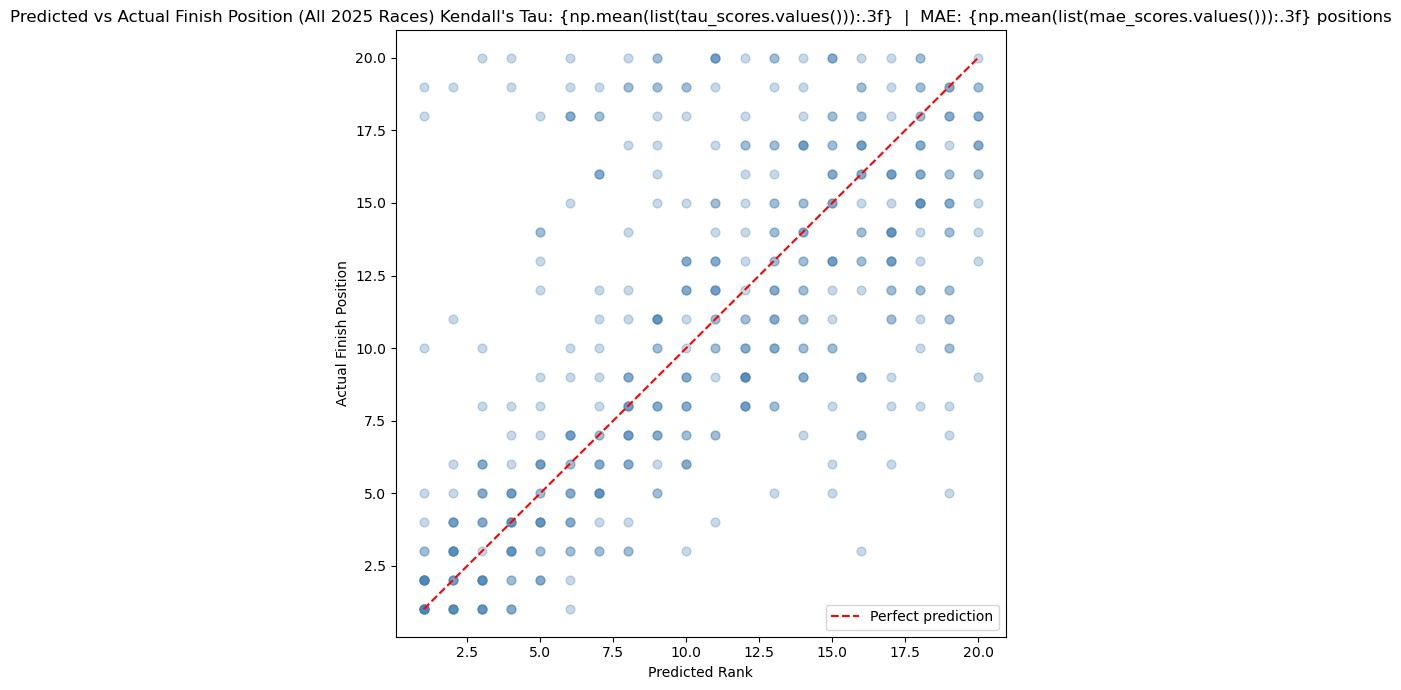

In [52]:
# Scatter plot: Predicted Rank vs Actual Finish (all races)
fig, ax = plt.subplots(figsize=(7, 7))

ax.scatter(df_eval_ref['Predicted_Rank'], df_eval_ref['FinishPosition'],
           alpha=0.3, edgecolors='steelblue', facecolors='steelblue', s=40)

# Perfect prediction line
ax.plot([1, 20], [1, 20], color='red', linestyle='--', linewidth=1.5, label='Perfect prediction')

ax.set_xlabel('Predicted Rank')
ax.set_ylabel('Actual Finish Position')
ax.set_title(f"Predicted vs Actual Finish Position (All 2025 Races) " + 
"Kendall's Tau: {np.mean(list(tau_scores.values())):.3f}  |  MAE: {np.mean(list(mae_scores.values())):.3f} positions")
ax.legend()
plt.tight_layout()
plt.show()

In [53]:
# Bar chart: per-race Kendall's Tau
races_sorted = sorted(tau_scores.items(), key=lambda x: x[1], reverse=True)
race_names = [r[0].replace(' Grand Prix', '') for r in races_sorted]
taus = [r[1] for r in races_sorted]
colors = ['steelblue' if t >= 0 else 'tomato' for t in taus]

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.barh(race_names, taus, color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.axvline(np.mean(taus), color='red', linestyle='--', linewidth=1.5, label=f'Mean: {np.mean(taus):.3f}')
ax.set_xlabel("Kendall's Tau")
ax.set_title("Per-Race Kendall's Tau — 2025 Season")
ax.legend()
plt.tight_layout()
plt.show()

AttributeError: 'list' object has no attribute 'items'